<a href="https://colab.research.google.com/github/IsaacGSolis/Mineria-de-Datos-IEGS/blob/main/RegresionLinealE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

In [39]:
datos=pd.read_csv('EdadSeguros.csv')
datos.columns=datos.columns.str.strip()
datos.head()

,Edad,Costo
0,18,22
1,22,24
2,23,55
3,25,27
4,27,85


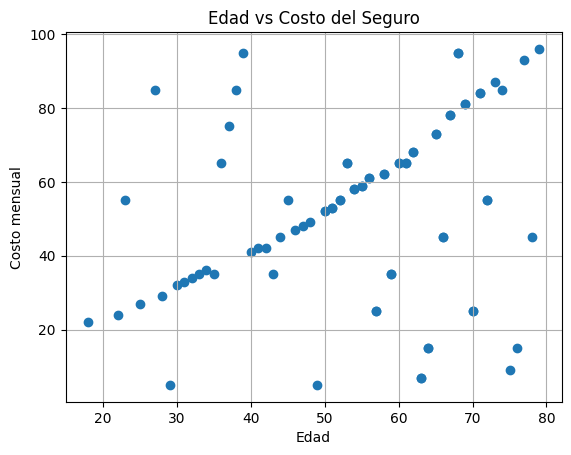

In [40]:
plt.scatter(datos["Edad"], datos["Costo"])
plt.title("Edad vs Costo del Seguro")
plt.xlabel("Edad")
plt.ylabel("Costo mensual")
plt.grid(True)
plt.show()

In [41]:
X=datos[['Edad']].values
Y=datos[['Costo']].values

In [42]:
modelo = LinearRegression()
modelo.fit(X, Y)
print("Pendiente:",modelo.coef_[0])
print("Intercepto:",modelo.intercept_)

Pendiente: [0.46070493]
Intercepto: [27.39960986]


In [43]:
X_sm=sm.add_constant(X)
modelo_sm=sm.OLS(Y, X_sm).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     7.377
Date:                Sun, 15 Mar 2026   Prob (F-statistic):            0.00813
Time:                        23:06:51   Log-Likelihood:                -364.04
No. Observations:                  80   AIC:                             732.1
Df Residuals:                      78   BIC:                             736.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.3996      9.479      2.891      0.0

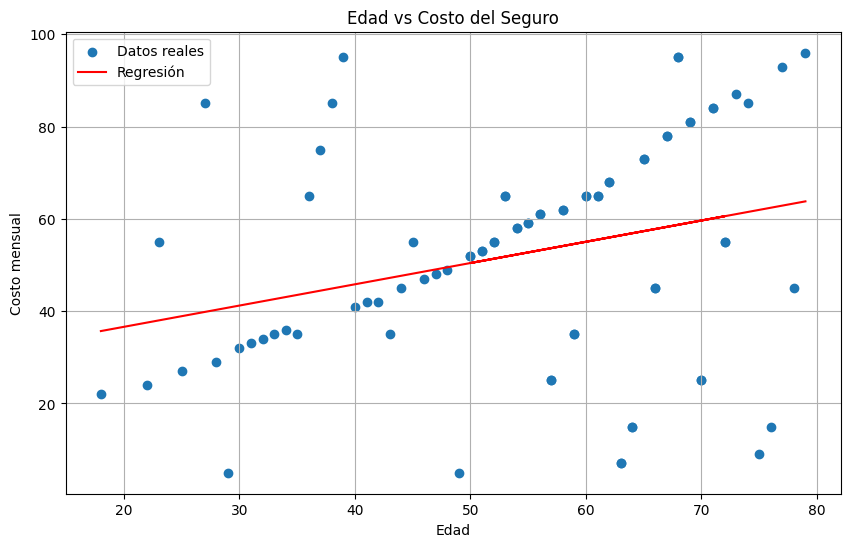

In [44]:
plt.figure(figsize=(10,6))
plt.scatter(X, Y, label="Datos reales")
plt.plot(X, modelo.predict(X), color="red", label="Regresión")
plt.title("Edad vs Costo del Seguro")
plt.xlabel("Edad")
plt.ylabel("Costo mensual")
plt.grid(True)
plt.legend()
plt.show()

In [45]:
edades=pd.DataFrame({"Edad":[30,40,50,60]})
predicciones=modelo.predict(edades)
tabla = edades.copy()
tabla["Costo_estimado"]=predicciones
tabla

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,Edad,Costo_estimado
0,30,41.220758
1,40,45.827807
2,50,50.434857
3,60,55.041906
